## Regressão Linear Múltipla

Dado um conjunto de observações

$$
V = \{(x_{i1}, x_{i2}, \dots, x_{ip}, y_i)\}_{i=1}^n
$$
    
queremos determinar o vetor de parâmetros $\beta$ tal que

$$
Y = X\beta + \varepsilon
$$

onde $X$, $Y$ e $\beta$ são dados por:
    
$$
  X =
  \begin{bmatrix}
  1 & x_{11} & x_{12} & \cdots & x_{1p} \\
  1 & x_{21} & x_{22} & \cdots & x_{2p} \\
  \vdots & \vdots & \vdots & \ddots & \vdots \\
  1 & x_{n1} & x_{n2} & \cdots & x_{np}
  \end{bmatrix},
  \qquad
  Y =
  \begin{bmatrix}
  y_1 \\ y_2 \\ \vdots \\ y_n
  \end{bmatrix},
  \qquad
  \beta =
  \begin{bmatrix}
  \beta_0 \\ \beta_1 \\ \vdots \\ \beta_p
  \end{bmatrix}.
$$

Seja

$$
\mathcal{L}(\beta) := \sum_{i=1}^{n} (y_i - x_i^{\top}\beta)^{2},
$$

a soma dos erros quadrados. Podemos reescrever:

\begin{align*}
    \mathcal{L}(\beta)
    &= \lVert Y - X\beta \rVert^{2} \\
    &= (Y - X\beta)^{\top}(Y - X\beta) \\
    &= Y^{\top}Y -Y^{\top}X\beta -(X\beta)^{\top}Y + (X\beta)^{\top}X\beta\\
    &= Y^{\top}Y - 2Y^{\top}X\beta + \beta^{\top}X^{\top}X\beta.
\end{align*}

Vamos derivar $\mathcal{L}$ com relação a $\beta$ e igualar a zero:

\begin{align*}
    \frac{d\mathcal{L}}{d\beta}
    &= \frac{d}{d\beta}\left(
        Y^{\top}Y
        - 2Y^{\top}X\beta
        + \beta^{\top}X^{\top}X\beta
    \right) \\
    &= 0 - 2X^{\top}Y + 2X^{\top}X\beta.
\end{align*}

Fazendo $\dfrac{d\mathcal{L}}{d\beta} = 0$, temos que:

\begin{align*}
    \dfrac{d\mathcal{L}}{d\beta} &= 0 \\
    -2X^{\top}Y + 2X^{\top}X\hat{\beta} &= 0 \\
    X^{\top}X\hat{\beta} &= X^{\top}Y \\
    \hat{\beta} &= (X^{\top}X)^{-1}X^{\top}Y.
\end{align*}

Assim, encontramos $\hat{\beta}$ que minimiza a soma dos erros quadrados.

## Aplicação

Um engarrafador deseja analisar o tempo que o motorista leva para abastecer e manter máquinas de venda automática em um ponto de venda. O objetivo é prever $Y :=$ tempo de serviço (em minutos) a partir das variáveis $X_1 :=$ número de caixas de produto abastecidas e $X_2 :=$ distância percorrida a pé pelo motorista (em metros). A seguir, apresentam-se os dados coletados em 25 observações:

| $n$    | 1   | 2   | 3   | 4   | 5   | 6   | 7   | 8   | 9   | 10  | 11  | 12  | 13  | 14  | 15  | 16  | 17  | 18  | 19  | 20  | 21  | 22  | 23  | 24  | 25  |
|--------|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| $X_1$  | 3   | 7   | 3   | 4   | 6   | 7   | 2   | 7   | 30  | 5   | 16  | 10  | 4   | 6   | 9   | 10  | 6   | 7   | 3   | 17  | 10  | 26  | 9   | 8   | 4   |
| $X_2$  | 560 | 220 | 340 | 80  | 150 | 330 | 110 | 210 | 1460| 605 | 688 | 215 | 255 | 462 | 448 | 776 | 200 | 132 | 36  | 770 | 140 | 810 | 450 | 635 | 150 |
| $Y$    | 16.68| 11.5| 12.03| 14.88| 13.75| 18.11| 8.0 | 17.83| 79.24| 21.5| 40.33| 21.0| 13.5| 19.75| 24.0| 29.0| 15.35| 19.0| 9.5 | 35.1| 17.9 | 52.32| 18.75| 19.83| 10.75|

Responda às seguintes perguntas:

1.   Os dados sugerem que o modelo de regressão múltipla descreve bem a relação entre $X_1$, $X_2$ e $Y$?
2.   Quais são as estimativas por mínimos quadrados de $\beta_0$, $\beta_1$ e $\beta_2$?
3. Obtenha a equação do plano de regressão estimado.
4. Preveja o tempo de serviço para um ponto de venda com $X_1 = 12$ caixas e $X_2 = 500$ metros.

### Solução

Análise do Gráfico de Dispersão de cada variável $X_i$ em relação a $Y$:

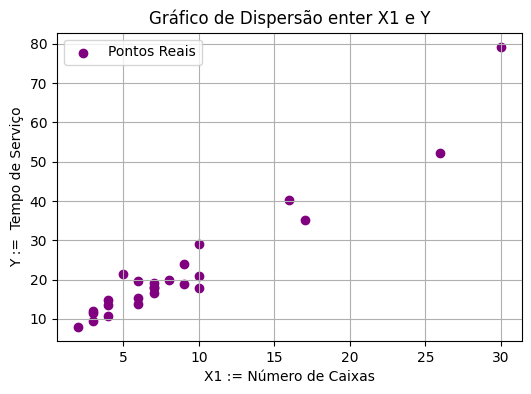

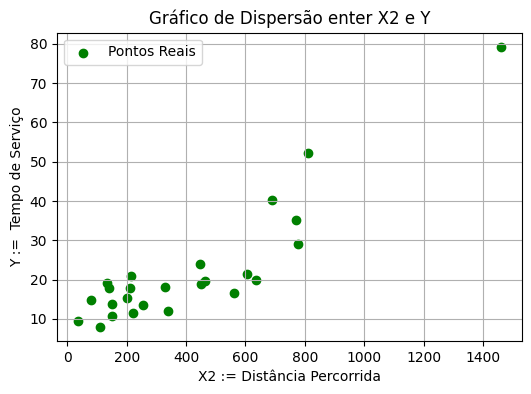

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X1 = np.array([7, 3, 3, 4, 6, 7, 2, 7, 30,
               5, 16, 10, 4, 6, 9, 10, 6,
               7, 3, 17, 10, 26, 9, 8, 4])

X2 = np.array([560, 220, 340, 80, 150, 330, 110, 210,
               1460, 605, 688, 215, 255, 462, 448, 776,
               200, 132, 36, 770, 140, 810, 450,635,150])

Y  = np.array([16.68, 11.50, 12.03, 14.88, 13.75, 18.11,8.00,17.83,
               79.24, 21.50, 40.33, 21.00, 13.50, 19.75, 24.00, 29.00,
               15.35, 19.00, 9.50, 35.10, 17.90, 52.32, 18.75, 19.83, 10.75])

plt.figure(figsize=(6,4))
plt.scatter(X1, Y, color='purple', label='Pontos Reais')
plt.xlabel("X1 := Número de Caixas")
plt.ylabel("Y :=  Tempo de Serviço")
plt.title("Gráfico de Dispersão enter X1 e Y")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(X2, Y, color='green', label='Pontos Reais')
plt.xlabel("X2 := Distância Percorrida")
plt.ylabel("Y :=  Tempo de Serviço")
plt.title("Gráfico de Dispersão enter X2 e Y")
plt.grid(True)
plt.legend()
plt.show()

Visualização do Gráfico de Dispersão entre $X_1$, $X_2$ e $Y$:

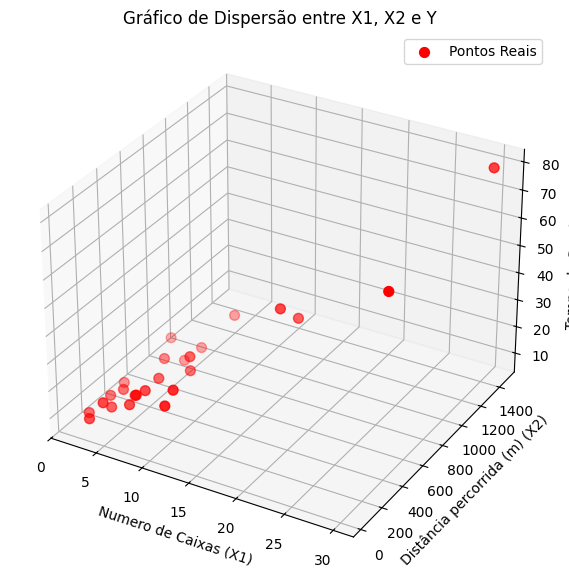

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X1 = np.array([7, 3, 3, 4, 6, 7, 2, 7, 30,
               5, 16, 10, 4, 6, 9, 10, 6,
               7, 3, 17, 10, 26, 9, 8, 4])

X2 = np.array([560, 220, 340, 80, 150, 330, 110, 210,
               1460, 605, 688, 215, 255, 462, 448, 776,
               200, 132, 36, 770, 140, 810, 450,635,150])

Y  = np.array([16.68, 11.50, 12.03, 14.88, 13.75, 18.11,8.00,17.83,
               79.24, 21.50, 40.33, 21.00, 13.50, 19.75, 24.00, 29.00,
               15.35, 19.00, 9.50, 35.10, 17.90, 52.32, 18.75, 19.83, 10.75])

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1, X2, Y, color="red", s=50, label='Pontos Reais')

ax.set_xlabel("Numero de Caixas (X1)")
ax.set_ylabel("Distância percorrida (m) (X2)")
ax.set_zlabel("Tempo de Serviço (Y)")
plt.title("Gráfico de Dispersão entre X1, X2 e Y")
plt.legend()
plt.show()


Os dados sugerem que um modelo de regressão múltipla descreve bem a relação entre as variáveis $X_1$, $X_2$ e $Y$.

Visualização de um plano genérico $y = a + bx_1 + cx_2$ e marcação dos resíduos:

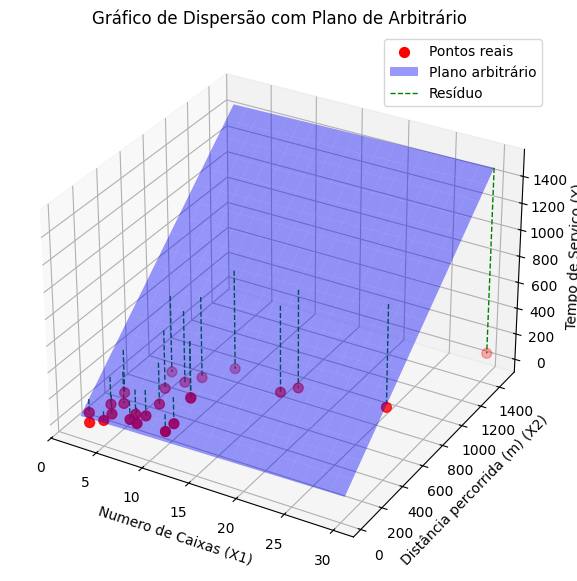

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X1 = np.array([7, 3, 3, 4, 6, 7, 2, 7, 30,
               5, 16, 10, 4, 6, 9, 10, 6,
               7, 3, 17, 10, 26, 9, 8, 4])

X2 = np.array([560, 220, 340, 80, 150, 330, 110, 210,
               1460, 605, 688, 215, 255, 462, 448, 776,
               200, 132, 36, 770, 140, 810, 450,635,150])

Y  = np.array([16.68, 11.50, 12.03, 14.88, 13.75, 18.11,8.00,17.83,
               79.24, 21.50, 40.33, 21.00, 13.50, 19.75, 24.00, 29.00,
               15.35, 19.00, 9.50, 35.10, 17.90, 52.32, 18.75, 19.83, 10.75])

x1_grid, x2_grid = np.meshgrid(
    np.linspace(min(X1), max(X1), 20),
    np.linspace(min(X2), max(X2), 20)
)

a, b, c = 1, 1, 1
y_plane = a + b*x1_grid + c*x2_grid

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1, X2, Y, color="red", s=50, label="Pontos reais")

ax.plot_surface(x1_grid, x2_grid, y_plane, alpha=0.4, color='blue', label='Plano arbitrário')

ax.plot([], [], [], color='green', linestyle='--', linewidth=1, label='Resíduo')

for x1i, x2i, yi in zip(X1, X2, Y):
    ypi = a + b*x1i + c*x2i
    residuo = yi - ypi

    ax.plot([x1i, x1i], [x2i, x2i], [ypi, yi], color='green', linestyle='--', linewidth=1)

ax.set_xlabel("Numero de Caixas (X1)")
ax.set_ylabel("Distância percorrida (m) (X2)")
ax.set_zlabel("Tempo de Serviço (Y)")
plt.title("Gráfico de Dispersão com Plano de Arbitrário")
plt.legend()
plt.show()



Cálculo da Regressão Linear Múltipla e Plano $y = \beta_0 + \beta_1x_1 + \beta_2x_2$ após minimização:



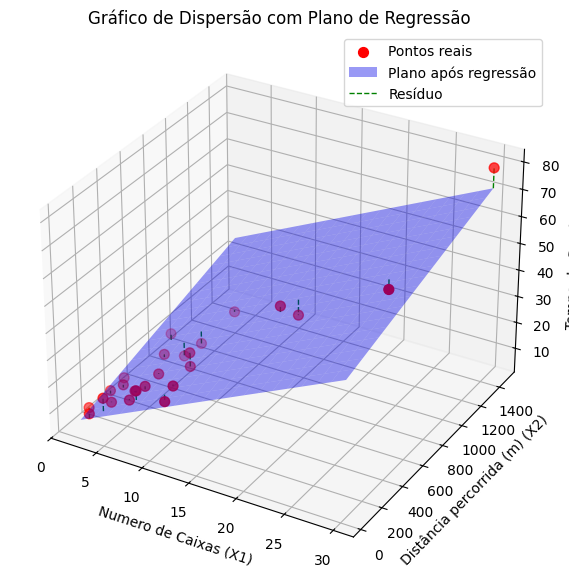

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X1 = np.array([7, 3, 3, 4, 6, 7, 2, 7, 30,
               5, 16, 10, 4, 6, 9, 10, 6,
               7, 3, 17, 10, 26, 9, 8, 4])

X2 = np.array([560, 220, 340, 80, 150, 330, 110, 210,
               1460, 605, 688, 215, 255, 462, 448, 776,
               200, 132, 36, 770, 140, 810, 450,635,150])

Y  = np.array([16.68, 11.50, 12.03, 14.88, 13.75, 18.11,8.00,17.83,
               79.24, 21.50, 40.33, 21.00, 13.50, 19.75, 24.00, 29.00,
               15.35, 19.00, 9.50, 35.10, 17.90, 52.32, 18.75, 19.83, 10.75])

x1_grid, x2_grid = np.meshgrid(
    np.linspace(min(X1), max(X1), 20),
    np.linspace(min(X2), max(X2), 20)
)

X = np.column_stack((np.ones(len(X1)), X1, X2))
beta = np.linalg.inv(X.T @ X) @ (X.T @ Y)
b0, b1, b2 = beta

y_plane = b0 + b1*x1_grid + b2*x2_grid

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1, X2, Y, color="red", s=50, label="Pontos reais")

ax.plot_surface(x1_grid, x2_grid, y_plane, alpha=0.4, color='blue', label='Plano após regressão')

ax.plot([], [], [], color='green', linestyle='--', linewidth=1, label='Resíduo')

for x1i, x2i, yi in zip(X1, X2, Y):
    ypi = b0 + b1*x1i + b2*x2i
    residuo = yi - ypi

    ax.plot([x1i, x1i], [x2i, x2i], [ypi, yi], color='green', linestyle='--', linewidth=1)


ax.set_xlabel("Numero de Caixas (X1)")
ax.set_ylabel("Distância percorrida (m) (X2)")
ax.set_zlabel("Tempo de Serviço (Y)")
plt.title("Gráfico de Dispersão com Plano de Regressão")
plt.legend()
plt.show()


Previsão para $X_1 = 12$ caixas e $X_2 = 500$ metros:

In [ ]:
x1 = 12
x2 = 500

y = b0 + b1*x1 + b2*x2

print(f"O tempo de serviço previsto é de {y:.2f} minutos")

O tempo de serviço previsto é de 28.92 minutos
